# 🛡️ A5 — Machine Learning Model: FP vs TP Classification
**Final Project MIKS — Security Operations Center (SOC)**

Dataset berasal dari Wazuh SIEM alerts yang sudah di-label oleh A4.  
Tugas A5: Bangun dan evaluasi model ML untuk mengklasifikasikan:
- **Label 0** → False Positive (traffic normal / noise)
- **Label 1** → True Positive (serangan nyata: DDoS, Malware, Anomali)

---
**Pipeline:**
1. Load & EDA
2. Preprocessing & Feature Engineering
3. Balancing (SMOTE)
4. Training (Random Forest + XGBoost)
5. Evaluasi & Visualisasi
6. Export Model

## 0️⃣ Install Dependencies

In [1]:
# Jalankan sekali saja jika belum ter-install
!pip install pandas numpy scikit-learn imbalanced-learn xgboost matplotlib seaborn joblib

'pip' is not recognized as an internal or external command,
operable program or batch file.


## 1️⃣ Load Dataset & EDA

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ⚠️ Sesuaikan path ini dengan lokasi file di komputer kamu
DATASET_PATH = 'dataset_final.csv'

df = pd.read_csv(DATASET_PATH)
print(f'Shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')
df.head()

Shape: (53278, 12)
Columns: ['timestamp', 'rule_id', 'rule_level', 'rule_description', 'rule_groups', 'agent_name', 'src_ip', 'dst_ip', 'dst_port', 'hit_count_60s', 'hour_of_day', 'label']


,timestamp,rule_id,rule_level,rule_description,rule_groups,agent_name,src_ip,dst_ip,dst_port,hit_count_60s,hour_of_day,label
0,2026-06-24 00:00:21.674000+00:00,5710,5,sshd: Attempt to login using a non-existent user,syslog|sshd|authentication_failed|invalid_login,agent-vm2,78.186.54.65,NaN,NaN,1,0,0
1,2026-06-24 00:00:50.661000+00:00,5710,5,sshd: Attempt to login using a non-existent user,syslog|sshd|authentication_failed|invalid_login,vm1-manager,91.92.40.176,NaN,NaN,1,0,0
2,2026-06-24 00:01:05.725000+00:00,5710,5,sshd: Attempt to login using a non-existent user,syslog|sshd|authentication_failed|invalid_login,agent-vm2,118.122.196.230,NaN,NaN,1,0,0
3,2026-06-24 00:01:46.339000+00:00,5710,5,sshd: Attempt to login using a non-existent user,syslog|sshd|authentication_failed|invalid_login,agent-vm2,14.29.214.161,NaN,NaN,1,0,0
4,2026-06-24 00:01:47.760000+00:00,5710,5,sshd: Attempt to login using a non-existent user,syslog|sshd|authentication_failed|invalid_login,agent-vm2,14.29.214.161,NaN,NaN,2,0,0


In [3]:
# Info dasar dataset
print('=== DATA TYPES ===')
print(df.dtypes)
print()
print('=== MISSING VALUES ===')
print(df.isnull().sum())
print()
print('=== LABEL DISTRIBUTION ===')
print(df['label'].value_counts())
print(f"\nRasio TP:FP = {df['label'].value_counts()[1]}:{df['label'].value_counts()[0]}")

=== DATA TYPES ===
timestamp            object
rule_id               int64
rule_level            int64
rule_description     object
rule_groups          object
agent_name           object
src_ip               object
dst_ip               object
dst_port            float64
hit_count_60s         int64
hour_of_day           int64
label                 int64
dtype: object

=== MISSING VALUES ===
timestamp              0
rule_id                0
rule_level             0
rule_description       1
rule_groups            0
agent_name             0
src_ip              5222
dst_ip              9347
dst_port            9347
hit_count_60s          0
hour_of_day            0
label                  0
dtype: int64

=== LABEL DISTRIBUTION ===
label
1    44023
0     9255
Name: count, dtype: int64

Rasio TP:FP = 44023:9255


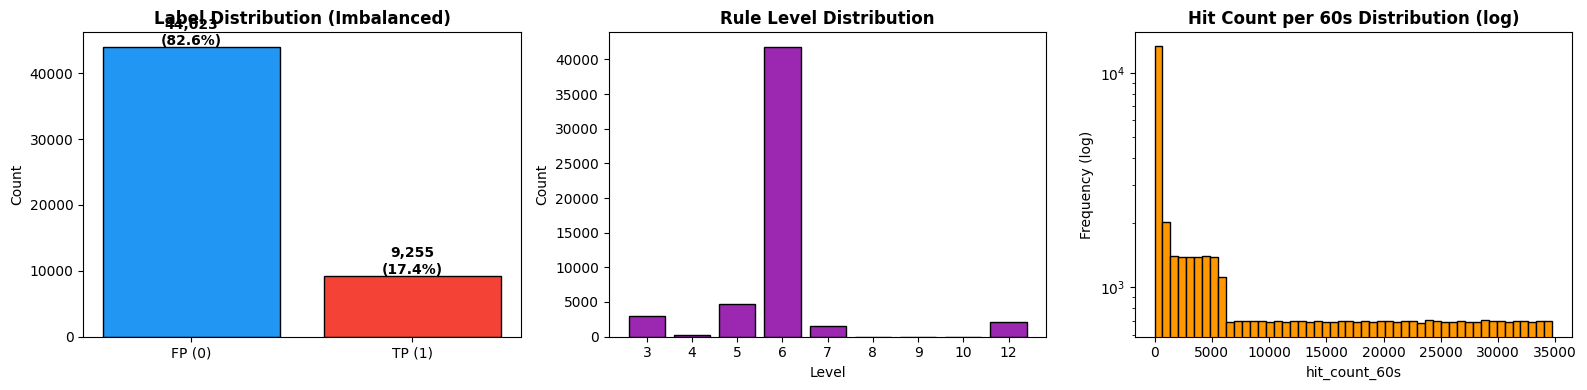

✅ Plot saved: 01_eda_overview.png


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Label distribution
label_counts = df['label'].value_counts()
axes[0].bar(['FP (0)', 'TP (1)'], label_counts.values, color=['#2196F3', '#F44336'], edgecolor='black')
axes[0].set_title('Label Distribution (Imbalanced)', fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(label_counts.values):
    axes[0].text(i, v + 300, f'{v:,}\n({v/len(df)*100:.1f}%)', ha='center', fontweight='bold')

# Rule level distribution
rule_level_counts = df['rule_level'].value_counts().sort_index()
axes[1].bar(rule_level_counts.index.astype(str), rule_level_counts.values, color='#9C27B0', edgecolor='black')
axes[1].set_title('Rule Level Distribution', fontweight='bold')
axes[1].set_xlabel('Level')
axes[1].set_ylabel('Count')

# hit_count_60s distribution (log scale)
axes[2].hist(df['hit_count_60s'], bins=50, color='#FF9800', edgecolor='black', log=True)
axes[2].set_title('Hit Count per 60s Distribution (log)', fontweight='bold')
axes[2].set_xlabel('hit_count_60s')
axes[2].set_ylabel('Frequency (log)')

plt.tight_layout()
plt.savefig('01_eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Plot saved: 01_eda_overview.png')

In [5]:
# Top Rule IDs dan Rule Descriptions
print('=== TOP 10 RULE IDs ===')
print(df['rule_id'].value_counts().head(10))
print()
print('=== TOP RULE DESCRIPTIONS ===')
for desc, cnt in df['rule_description'].value_counts().head(8).items():
    print(f'  [{cnt:>6}]  {str(desc)[:80]}')

=== TOP 10 RULE IDs ===
rule_id
100010    41822
5710       3827
100011     2108
651        2094
554         809
553         807
550         616
86003       360
5762        260
5501        157
Name: count, dtype: int64

=== TOP RULE DESCRIPTIONS ===
  [ 41822]  IPTables: Deteksi awal traffic SYN yang mencurigakan (Indikasi DDoS).
  [  3827]  sshd: Attempt to login using a non-existent user
  [  2108]  🔴 CRITICAL: Kemungkinan Serangan SYN Flood DDoS Sedang Berlangsung!
  [  2094]  Host Blocked by firewall-drop Active Response
  [   809]  File added to the system.
  [   807]  File deleted.
  [   616]  Integrity checksum changed.
  [   360]  Docker: Error message


## 2️⃣ Preprocessing & Feature Engineering

In [6]:
from sklearn.preprocessing import LabelEncoder

df_proc = df.copy()

# --- Timestamp: ekstrak fitur waktu ---
df_proc['timestamp'] = pd.to_datetime(df_proc['timestamp'], format='mixed', utc=True)
df_proc['day_of_week'] = df_proc['timestamp'].dt.dayofweek  # 0=Senin, 6=Minggu
df_proc['minute_of_hour'] = df_proc['timestamp'].dt.minute
df_proc.drop(columns=['timestamp'], inplace=True)
print('✅ Timestamp extracted (day_of_week, minute_of_hour)')

# --- src_ip: apakah IP internal Azure (10.0.0.x)? ---
def is_internal_ip(ip):
    if pd.isna(ip):
        return -1  # unknown
    return 1 if str(ip).startswith('10.') else 0

df_proc['src_ip_is_internal'] = df_proc['src_ip'].apply(is_internal_ip)
df_proc['src_ip_is_attacker'] = (df_proc['src_ip'] == '10.0.0.6').astype(int)
df_proc.drop(columns=['src_ip'], inplace=True)
print('✅ src_ip engineered (is_internal, is_attacker)')

# --- dst_ip & dst_port: fill missing dengan 0 ---
df_proc['dst_ip_is_target'] = (df_proc['dst_ip'] == 10.0).astype(int)  # dst_ip disimpan float
df_proc['dst_port'].fillna(0, inplace=True)
df_proc.drop(columns=['dst_ip'], inplace=True)
print('✅ dst_ip & dst_port handled')

# --- rule_description: 1 row missing, fill dengan 'unknown' ---
df_proc['rule_description'].fillna('unknown', inplace=True)

# --- Categorical Encoding ---
# agent_name -> label encode (hanya 3 nilai)
le_agent = LabelEncoder()
df_proc['agent_name'] = le_agent.fit_transform(df_proc['agent_name'])
print(f'✅ agent_name encoded: {dict(zip(le_agent.classes_, le_agent.transform(le_agent.classes_)))}')

# rule_id -> tetap sebagai numerik (sudah integer)
# rule_groups -> count berapa banyak group (pisah oleh '|')
df_proc['rule_groups_count'] = df_proc['rule_groups'].str.split('|').apply(len)
# Flag: apakah termasuk group ddos/attack?
df_proc['is_ddos_group'] = df_proc['rule_groups'].str.contains('ddos|attack', case=False).astype(int)
df_proc.drop(columns=['rule_groups'], inplace=True)
print('✅ rule_groups engineered (count, is_ddos_group)')

# rule_description: flag keyword penting
df_proc['desc_is_syn'] = df_proc['rule_description'].str.contains('SYN|Flood|DDoS', case=False).astype(int)
df_proc['desc_is_ssh'] = df_proc['rule_description'].str.contains('ssh|login|password', case=False).astype(int)
df_proc['desc_is_fim'] = df_proc['rule_description'].str.contains('file|integrity|checksum', case=False).astype(int)
df_proc.drop(columns=['rule_description'], inplace=True)
print('✅ rule_description engineered (desc_is_syn, desc_is_ssh, desc_is_fim)')

print()
print('=== FINAL FEATURES ===')
print(df_proc.columns.tolist())
print(f'Shape: {df_proc.shape}')
print()
print('Missing values after preprocessing:')
print(df_proc.isnull().sum())

✅ Timestamp extracted (day_of_week, minute_of_hour)
✅ src_ip engineered (is_internal, is_attacker)
✅ dst_ip & dst_port handled
✅ agent_name encoded: {'agent-vm2': np.int64(0), 'agent-vm3': np.int64(1), 'vm1-manager': np.int64(2)}
✅ rule_groups engineered (count, is_ddos_group)
✅ rule_description engineered (desc_is_syn, desc_is_ssh, desc_is_fim)

=== FINAL FEATURES ===
['rule_id', 'rule_level', 'agent_name', 'dst_port', 'hit_count_60s', 'hour_of_day', 'label', 'day_of_week', 'minute_of_hour', 'src_ip_is_internal', 'src_ip_is_attacker', 'dst_ip_is_target', 'rule_groups_count', 'is_ddos_group', 'desc_is_syn', 'desc_is_ssh', 'desc_is_fim']
Shape: (53278, 17)

Missing values after preprocessing:
rule_id               0
rule_level            0
agent_name            0
dst_port              0
hit_count_60s         0
hour_of_day           0
label                 0
day_of_week           0
minute_of_hour        0
src_ip_is_internal    0
src_ip_is_attacker    0
dst_ip_is_target      0
rule_groups

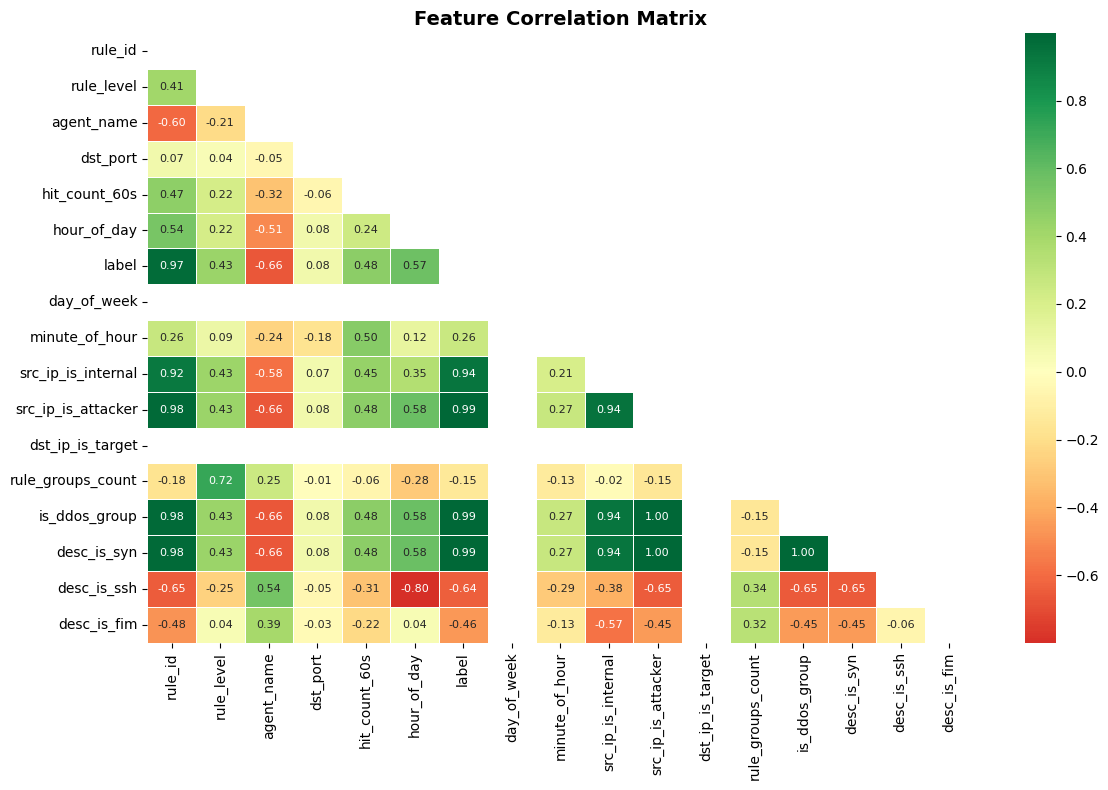

✅ Plot saved: 02_correlation_matrix.png


In [7]:
# Correlation heatmap
plt.figure(figsize=(12, 8))
corr = df_proc.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.5, annot_kws={'size': 8})
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('02_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Plot saved: 02_correlation_matrix.png')

## 3️⃣ Train-Test Split & SMOTE Balancing

In [9]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

X = df_proc.drop(columns=['label'])
y = df_proc['label']

# Split 80:20, stratified agar proporsi label tetap terjaga
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('=== BEFORE SMOTE ===')
print(f'Train size : {X_train.shape[0]:,}')
print(f'Test size  : {X_test.shape[0]:,}')
print(f'Train label distribution:')
print(y_train.value_counts())

# SMOTE hanya diterapkan pada TRAINING SET
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print()
print('=== AFTER SMOTE ===')
print(f'Train size : {X_train_sm.shape[0]:,}')
print(f'Train label distribution:')
print(pd.Series(y_train_sm).value_counts())
print(f'✅ Dataset seimbang 50:50!')

=== BEFORE SMOTE ===
Train size : 42,622
Test size  : 10,656
Train label distribution:
label
1    35218
0     7404
Name: count, dtype: int64

=== AFTER SMOTE ===
Train size : 70,436
Train label distribution:
label
1    35218
0    35218
Name: count, dtype: int64
✅ Dataset seimbang 50:50!


## 4️⃣ Model Training

In [11]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report, confusion_matrix
)
import time

models = {
    'Random Forest': RandomForestClassifier(
        n_estimators=100,
        max_depth=15,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    ),
    'XGBoost': XGBClassifier(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric='logloss',
        verbosity=0
    ),
    'Logistic Regression': LogisticRegression(
        max_iter=1000,
        random_state=42
    )
}

results = {}

for name, model in models.items():
    print(f'⏳ Training {name}...')
    t0 = time.time()
    model.fit(X_train_sm, y_train_sm)
    t1 = time.time()

    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    results[name] = {
        'model': model,
        'accuracy':  accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall':    recall_score(y_test, y_pred),
        'f1':        f1_score(y_test, y_pred),
        'roc_auc':   roc_auc_score(y_test, y_proba),
        'y_pred':    y_pred,
        'y_proba':   y_proba,
        'train_time': t1 - t0
    }
    print(f'   ✅ Done in {t1-t0:.2f}s | Accuracy: {results[name]["accuracy"]:.4f} | F1: {results[name]["f1"]:.4f} | ROC-AUC: {results[name]["roc_auc"]:.4f}')
    print()

print('🎯 All models trained!')

⏳ Training Random Forest...
   ✅ Done in 0.50s | Accuracy: 0.9999 | F1: 0.9999 | ROC-AUC: 1.0000

⏳ Training XGBoost...
   ✅ Done in 0.61s | Accuracy: 0.9999 | F1: 0.9999 | ROC-AUC: 1.0000

⏳ Training Logistic Regression...
   ✅ Done in 1.59s | Accuracy: 0.9997 | F1: 0.9998 | ROC-AUC: 1.0000

🎯 All models trained!


## 5️⃣ Evaluasi & Visualisasi

In [12]:
# Tabel perbandingan semua model
summary = pd.DataFrame({
    name: {
        'Accuracy':  f"{res['accuracy']:.4f}",
        'Precision': f"{res['precision']:.4f}",
        'Recall':    f"{res['recall']:.4f}",
        'F1-Score':  f"{res['f1']:.4f}",
        'ROC-AUC':   f"{res['roc_auc']:.4f}",
        'Train Time': f"{res['train_time']:.2f}s"
    }
    for name, res in results.items()
}).T

print('=== MODEL COMPARISON ===')
print(summary.to_string())
summary

=== MODEL COMPARISON ===
                    Accuracy Precision  Recall F1-Score ROC-AUC Train Time
Random Forest         0.9999    1.0000  0.9999   0.9999  1.0000      0.50s
XGBoost               0.9999    1.0000  0.9999   0.9999  1.0000      0.61s
Logistic Regression   0.9997    1.0000  0.9997   0.9998  1.0000      1.59s


,Accuracy,Precision,Recall,F1-Score,ROC-AUC,Train Time
Random Forest,0.9999,1.0000,0.9999,0.9999,1.0000,0.50s
XGBoost,0.9999,1.0000,0.9999,0.9999,1.0000,0.61s
Logistic Regression,0.9997,1.0000,0.9997,0.9998,1.0000,1.59s


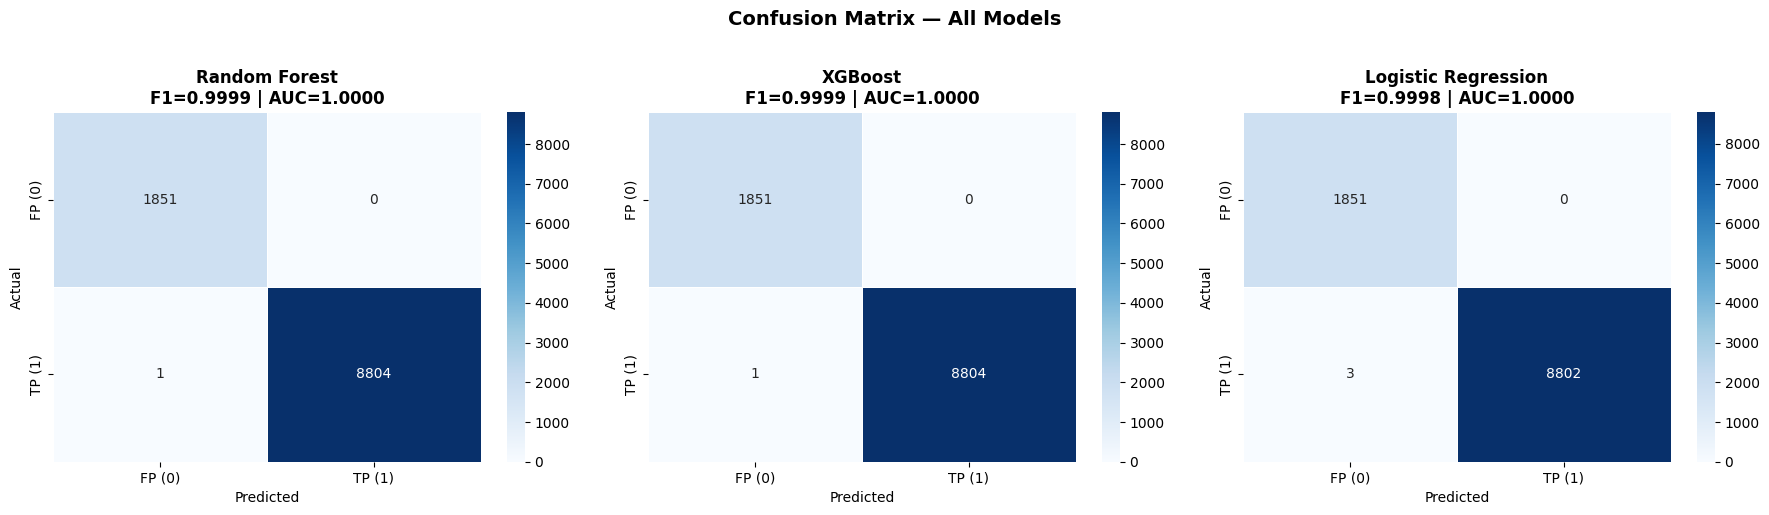

✅ Plot saved: 03_confusion_matrix.png


In [13]:
# Confusion Matrix untuk semua model
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=['FP (0)', 'TP (1)'],
        yticklabels=['FP (0)', 'TP (1)'],
        ax=ax, linewidths=0.5
    )
    ax.set_title(f'{name}\nF1={res["f1"]:.4f} | AUC={res["roc_auc"]:.4f}', fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrix — All Models', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('03_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Plot saved: 03_confusion_matrix.png')

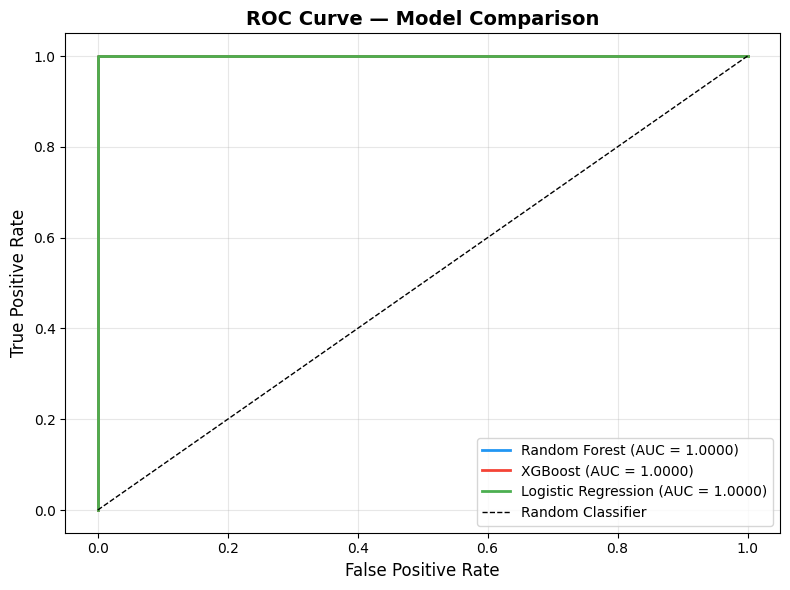

✅ Plot saved: 04_roc_curve.png


In [14]:
from sklearn.metrics import roc_curve

# ROC Curve
plt.figure(figsize=(8, 6))
colors = ['#2196F3', '#F44336', '#4CAF50']

for (name, res), color in zip(results.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, res['y_proba'])
    plt.plot(fpr, tpr, color=color, lw=2,
             label=f"{name} (AUC = {res['roc_auc']:.4f})")

plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve — Model Comparison', fontsize=14, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('04_roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Plot saved: 04_roc_curve.png')

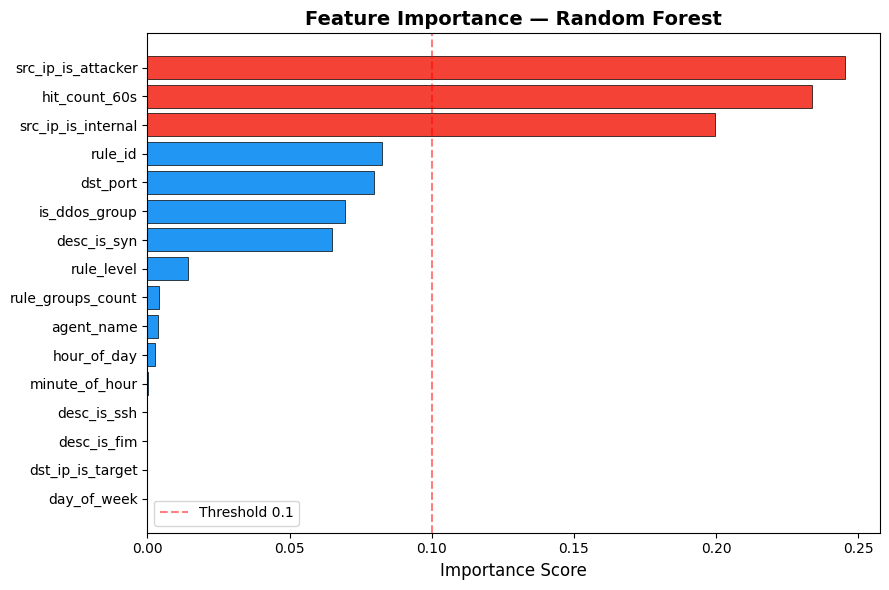

✅ Plot saved: 05_feature_importance.png

Top 5 most important features:
src_ip_is_attacker    0.245372
hit_count_60s         0.233826
src_ip_is_internal    0.199478
rule_id               0.082377
dst_port              0.079544


In [15]:
# Feature Importance — Random Forest
rf_model = results['Random Forest']['model']
feat_imp = pd.Series(rf_model.feature_importances_, index=X.columns)
feat_imp_sorted = feat_imp.sort_values(ascending=True)

plt.figure(figsize=(9, 6))
colors_bar = ['#F44336' if v > 0.1 else '#2196F3' for v in feat_imp_sorted.values]
plt.barh(feat_imp_sorted.index, feat_imp_sorted.values, color=colors_bar, edgecolor='black', linewidth=0.5)
plt.xlabel('Importance Score', fontsize=12)
plt.title('Feature Importance — Random Forest', fontsize=14, fontweight='bold')
plt.axvline(x=0.1, color='red', linestyle='--', alpha=0.5, label='Threshold 0.1')
plt.legend()
plt.tight_layout()
plt.savefig('05_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Plot saved: 05_feature_importance.png')

print()
print('Top 5 most important features:')
print(feat_imp.sort_values(ascending=False).head(5).to_string())

In [16]:
# Classification Report — Best Model (biasanya RF atau XGBoost)
best_model_name = max(results, key=lambda x: results[x]['f1'])
best_res = results[best_model_name]

print(f'🏆 Best Model: {best_model_name}')
print(f'   F1-Score : {best_res["f1"]:.4f}')
print(f'   ROC-AUC  : {best_res["roc_auc"]:.4f}')
print()
print('=== CLASSIFICATION REPORT ===')
print(classification_report(
    y_test, best_res['y_pred'],
    target_names=['False Positive (0)', 'True Positive (1)']
))

🏆 Best Model: Random Forest
   F1-Score : 0.9999
   ROC-AUC  : 1.0000

=== CLASSIFICATION REPORT ===
                    precision    recall  f1-score   support

False Positive (0)       1.00      1.00      1.00      1851
 True Positive (1)       1.00      1.00      1.00      8805

          accuracy                           1.00     10656
         macro avg       1.00      1.00      1.00     10656
      weighted avg       1.00      1.00      1.00     10656



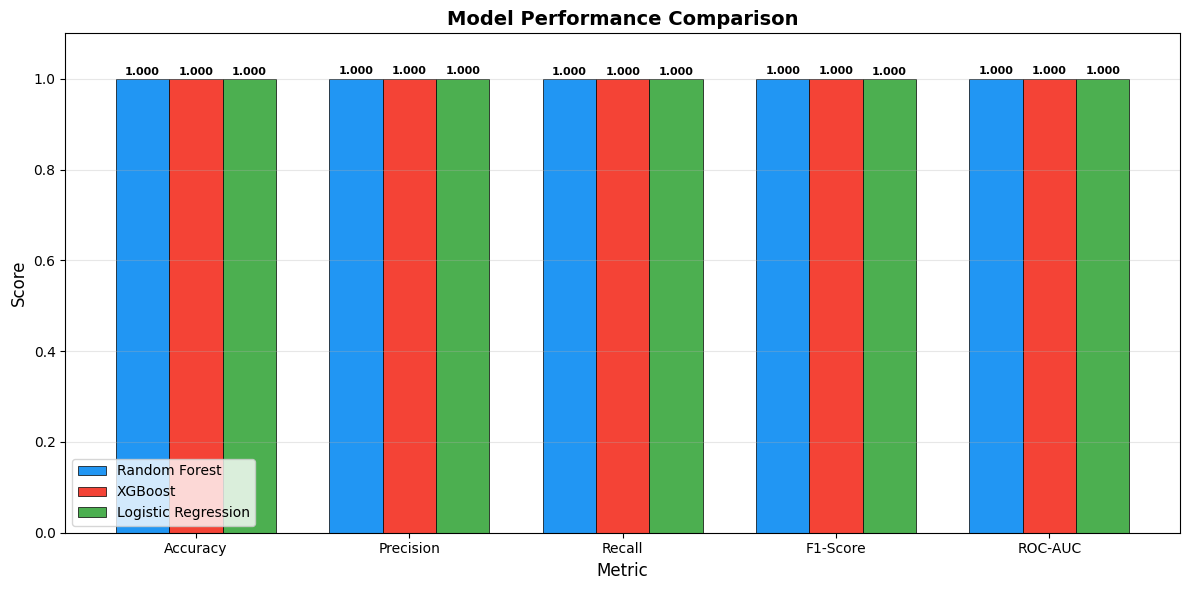

✅ Plot saved: 06_model_comparison.png


In [17]:
# Bar chart perbandingan metrik semua model
metrics = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
metric_labels = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']

x = np.arange(len(metrics))
width = 0.25
colors_model = ['#2196F3', '#F44336', '#4CAF50']

fig, ax = plt.subplots(figsize=(12, 6))

for i, (name, res) in enumerate(results.items()):
    vals = [res[m] for m in metrics]
    bars = ax.bar(x + i * width, vals, width, label=name, color=colors_model[i], edgecolor='black', linewidth=0.5)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.set_xlabel('Metric', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x + width)
ax.set_xticklabels(metric_labels)
ax.set_ylim(0, 1.1)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('06_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Plot saved: 06_model_comparison.png')

## 6️⃣ Export Model

In [18]:
import joblib

# Simpan best model
best_model = results[best_model_name]['model']
joblib.dump(best_model, f'soc_model_{best_model_name.lower().replace(" ", "_")}.pkl')
print(f'✅ Best model saved: soc_model_{best_model_name.lower().replace(" ", "_")}.pkl')

# Simpan juga feature names untuk inferensi
feature_names = X.columns.tolist()
joblib.dump(feature_names, 'feature_names.pkl')
print(f'✅ Feature names saved: feature_names.pkl')

# Simpan semua model
for name, res in results.items():
    filename = f'model_{name.lower().replace(" ", "_")}.pkl'
    joblib.dump(res['model'], filename)
    print(f'   Saved: {filename}')

print()
print('=== SUMMARY FINAL ===')
print(summary)

✅ Best model saved: soc_model_random_forest.pkl
✅ Feature names saved: feature_names.pkl
   Saved: model_random_forest.pkl
   Saved: model_xgboost.pkl
   Saved: model_logistic_regression.pkl

=== SUMMARY FINAL ===
                    Accuracy Precision  Recall F1-Score ROC-AUC Train Time
Random Forest         0.9999    1.0000  0.9999   0.9999  1.0000      0.50s
XGBoost               0.9999    1.0000  0.9999   0.9999  1.0000      0.61s
Logistic Regression   0.9997    1.0000  0.9997   0.9998  1.0000      1.59s


## 📋 Cara Load & Gunakan Model (untuk Inferensi)

```python
import joblib
import pandas as pd

# Load model dan feature names
model = joblib.load('soc_model_random_forest.pkl')
feature_names = joblib.load('feature_names.pkl')

# Contoh data baru (pastikan urutan kolom sama!)
new_data = pd.DataFrame([{
    'rule_id': 100011,
    'rule_level': 12,
    'agent_name': 0,          # agent-vm2 = 0, agent-vm3 = 1, vm1-manager = 2
    'dst_port': 80.0,
    'hit_count_60s': 250,
    'hour_of_day': 14,
    'day_of_week': 1,
    'minute_of_hour': 32,
    'src_ip_is_internal': 1,
    'src_ip_is_attacker': 1,
    'dst_ip_is_target': 0,
    'rule_groups_count': 4,
    'is_ddos_group': 1,
    'desc_is_syn': 1,
    'desc_is_ssh': 0,
    'desc_is_fim': 0
}])[feature_names]

prediction = model.predict(new_data)
probability = model.predict_proba(new_data)[:, 1]
print(f'Prediksi: {"TP (Serangan)" if prediction[0] == 1 else "FP (Normal)"}')
print(f'Probabilitas TP: {probability[0]:.4f}')
```